In [1]:
import pandas as pd

# Load both files
true_df = pd.read_csv('../data/True.csv')
fake_df = pd.read_csv('../data/Fake.csv')

# Label them: 1 = Real, 0 = Fake
true_df['label'] = 1
fake_df['label'] = 0

# Combine into one dataframe
df = pd.concat([true_df, fake_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle rows

print(df.shape)
print(df['label'].value_counts())
df.head()

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [2]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate rows
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

title      0
text       0
subject    0
date       0
label      0
dtype: int64
Duplicates: 209


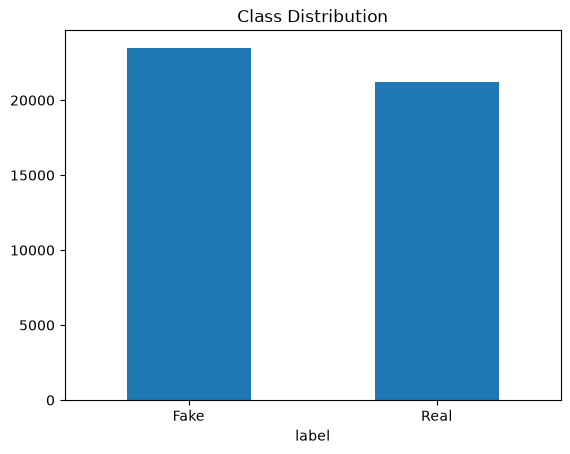

In [3]:
# Class balance chart
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['Fake', 'Real'], rotation=0)
plt.title('Class Distribution')
plt.show()

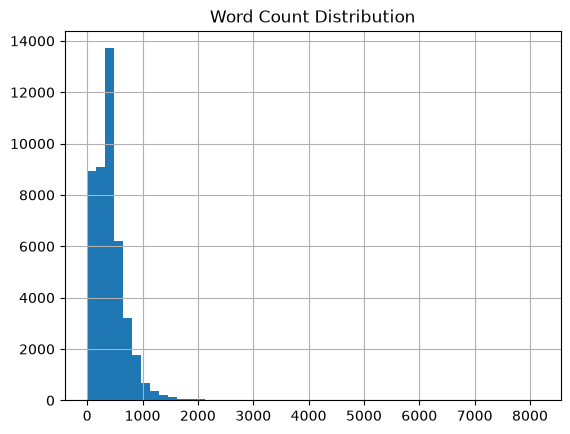

In [4]:
# Combine title + text into one field
df['content'] = df['title'] + " " + df['text']

# Article length distribution
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))
df['word_count'].hist(bins=50)
plt.title('Word Count Distribution')
plt.show()

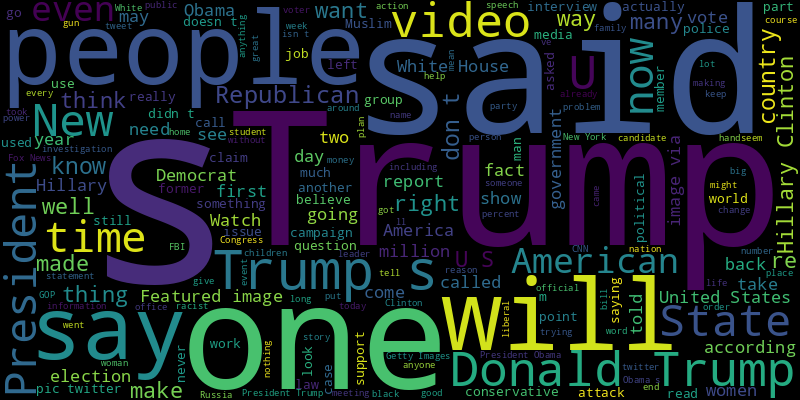

In [5]:
# Word clouds for fake vs real
from wordcloud import WordCloud

fake_text = " ".join(df[df['label']==0]['content'].astype(str).tolist()[:2000])
real_text = " ".join(df[df['label']==1]['content'].astype(str).tolist()[:2000])

WordCloud(width=800, height=400).generate(fake_text).to_image()

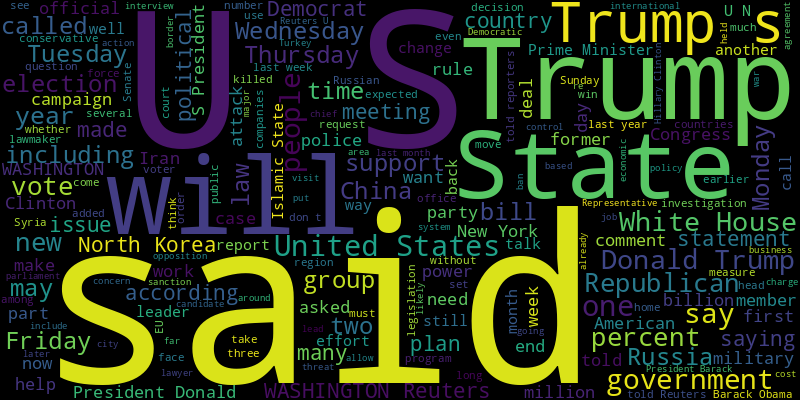

In [6]:
WordCloud(width=800, height=400).generate(real_text).to_image()

In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\geeth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\geeth\AppData\Roaming\nltk_data...


True

In [8]:
import sys
sys.path.append('../src')
from clean_text import clean_text

df['clean_text'] = df['content'].apply(clean_text)
df[['content', 'clean_text']].head()

,content,clean_text
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley enough demand t...
1,Failed GOP Candidates Remembered In Hilarious...,failed gop candidate remembered hilarious mock...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pences new dc neighbor hilariously trolli...
3,California AG pledges to defend birth control ...,california ag pledge defend birth control insu...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,az rancher living usmexico border destroy nanc...


In [9]:
df.to_csv('../data/cleaned_data.csv', index=False)
print("Saved!")

Saved!


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

# Split BEFORE vectorizing to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)   # fit only on train
X_test_tfidf = vectorizer.transform(X_test)          # transform test using same vocab

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=50)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds, target_names=['Fake','Real']))

c:\Users\geeth\OneDrive\Desktop\Capstone_project\fake-news-analyser\venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)



--- Logistic Regression ---
Accuracy: 0.9865741776683822
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4696
        Real       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938


--- Naive Bayes ---
Accuracy: 0.9314164242559857
              precision    recall  f1-score   support

        Fake       0.93      0.94      0.93      4696
        Real       0.93      0.92      0.93      4242

    accuracy                           0.93      8938
   macro avg       0.93      0.93      0.93      8938
weighted avg       0.93      0.93      0.93      8938


--- Passive Aggressive ---
Accuracy: 0.9949653166256434
              precision    recall  f1-score   support

        Fake       0.99      1.00      1.00      4696
        Real       1.00      0.99      0.99      4242

    accuracy     

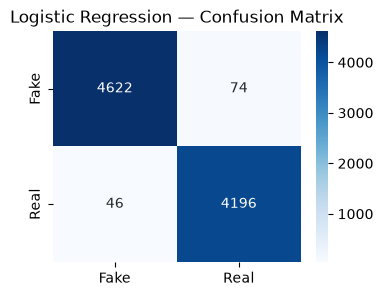

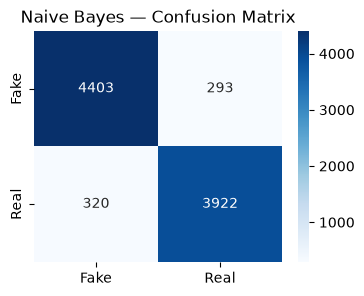

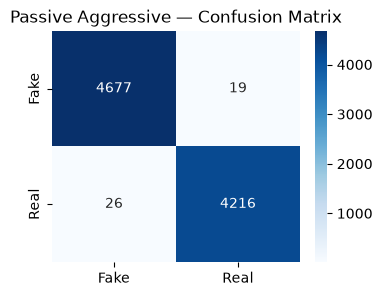


Model comparison:
Logistic Regression: 0.9866
Naive Bayes: 0.9314
Passive Aggressive: 0.9950


In [12]:
import seaborn as sns

for name, model in models.items():
    preds = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(f'{name} — Confusion Matrix')
    plt.show()

print("\nModel comparison:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

In [13]:
import joblib

final_model = models["Passive Aggressive"]

joblib.dump(final_model, '../models/fake_news_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
print("Saved successfully.")

Saved successfully.


In [14]:
ls ../models

Invalid switch - "models".
